In [7]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install tensorflow scikit-learn 

In [8]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import matplotlib.pyplot as plt

In [9]:
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('../../datos_activo.csv')

#df.drop(columns=['Date'], inplace=True)  # Eliminar columna de fecha
df.head()

,Close,High,Low,Open,Volume,return,target,range,volume_change,close_ma5,close_ma20,return_vol5,return_vol20,lag_1,lag_2,lag_3,lag_6,lag_12
0,0.349069,0.349069,0.328994,0.330342,529496800,0.063927,0.012017,0.057509,2.842993,0.333159,0.326709,0.031891,0.033359,-0.023631,0.016313,0.026989,0.015965,-0.022801
1,0.353264,0.355811,0.341129,0.344574,612007200,0.012017,0.004666,0.041561,0.155828,0.339421,0.327593,0.031447,0.030456,0.063927,-0.023631,0.016313,0.017144,-0.029048
2,0.354912,0.358807,0.344425,0.349668,409976000,0.004666,-0.033347,0.040524,-0.330112,0.344275,0.327541,0.031635,0.027280,0.012017,0.063927,-0.023631,0.006085,0.011280
3,0.343077,0.359556,0.340829,0.355361,444584000,-0.033347,-0.012665,0.054584,0.084415,0.345683,0.327630,0.038117,0.026699,0.004666,0.012017,0.063927,0.026989,0.018916
4,0.338732,0.345324,0.336484,0.340829,450038400,-0.012665,-0.042459,0.026095,0.012269,0.347811,0.327683,0.036352,0.026750,-0.033347,0.004666,0.012017,0.016313,0.029031


In [10]:
n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train = df.iloc[:n_train]
val = df.iloc[n_train:n_train + n_val]
test = df.iloc[n_train + n_val:]

In [11]:
feature_cols = [c for c in df.columns if c != 'target']

X_train_lgb = train[feature_cols]
y_train_lgb = train['target']
X_val_lgb = val[feature_cols]
y_val_lgb = val['target']
X_test_lgb = test[feature_cols]
y_test_lgb = test['target']

print(f"Train: {X_train_lgb.shape}, Val: {X_val_lgb.shape}, Test: {X_test_lgb.shape}")


Train: (4253, 17), Val: (911, 17), Test: (913, 17)


In [13]:
# Para LSTM: necesitamos la columna 'Close' en secuencia
precio_train = train['Close'].values
precio_val = val['Close'].values
precio_test = test['Close'].values

In [14]:
INPUT_LENGTH = 6  # Ventana de 6 meses

def crear_secuencias_precio(precios, input_length):
    X_seq = []
    for i in range(len(precios) - input_length):
        X_seq.append(precios[i:i+input_length])
    return np.array(X_seq).reshape(-1, input_length, 1)

X_train_seq = crear_secuencias_precio(precio_train, INPUT_LENGTH)
X_val_seq = crear_secuencias_precio(precio_val, INPUT_LENGTH)
X_test_seq = crear_secuencias_precio(precio_test, INPUT_LENGTH)

# Ajustar targets para que coincidan con las secuencias (recortar primeras INPUT_LENGTH)
y_train_seq = y_train_lgb.iloc[INPUT_LENGTH:].values
y_val_seq = y_val_lgb.iloc[INPUT_LENGTH:].values
y_test_seq = y_test_lgb.iloc[INPUT_LENGTH:].values

In [15]:
# Escalar para LSTM
scaler_lstm = StandardScaler()
X_train_reshaped = X_train_seq.reshape(-1, 1)
X_val_reshaped = X_val_seq.reshape(-1, 1)
X_test_reshaped = X_test_seq.reshape(-1, 1)

scaler_lstm.fit(X_train_reshaped)
X_train_scaled = scaler_lstm.transform(X_train_reshaped).reshape(X_train_seq.shape)
X_val_scaled = scaler_lstm.transform(X_val_reshaped).reshape(X_val_seq.shape)
X_test_scaled = scaler_lstm.transform(X_test_reshaped).reshape(X_test_seq.shape)

In [16]:
# Construir LSTM extractor de features
lstm_input = Input(shape=(INPUT_LENGTH, 1))
x = LSTM(16, return_sequences=True, dropout=0.2)(lstm_input)
x = LSTM(8, return_sequences=False, dropout=0.2)(x)
feature_extractor = Model(inputs=lstm_input, outputs=x)

In [17]:
# Modelo completo para entrenar
output = Dense(1)(x)
lstm_model = Model(inputs=lstm_input, outputs=output)
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 16)          │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,961 (7.66 KB)

 Trainable params: 1,961 (7.66 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Entrenar LSTM
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lstm_model.fit(
    X_train_scaled, y_train_seq,
    validation_data=(X_val_scaled, y_val_seq),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 7.5352e-04 - val_loss: 7.1673e-04
Epoch 2/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.0006e-04 - val_loss: 5.8187e-04
Epoch 3/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.9023e-04 - val_loss: 6.6741e-04
Epoch 4/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8778e-04 - val_loss: 5.6533e-04
Epoch 5/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8791e-04 - val_loss: 5.9119e-04
Epoch 6/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8621e-04 - val_loss: 6.2375e-04
Epoch 7/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8431e-04 - val_loss: 5.1735e-04
Epoch 8/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8324e-04 - val_loss: 5.6031e-04
Epoch 9/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8260e-04 - val_loss: 5.3770e-04
Epoch 10/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8178e-04 - val_loss: 4.7928e-04
Epoch 11/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

In [19]:
# Extraer features LSTM
lstm_features_train = feature_extractor.predict(X_train_scaled, verbose=0)
lstm_features_val = feature_extractor.predict(X_val_scaled, verbose=0)
lstm_features_test = feature_extractor.predict(X_test_scaled, verbose=0)

# Preparar datos híbridos (LGBM + features LSTM)
X_train_hybrid = np.hstack([X_train_lgb.iloc[INPUT_LENGTH:].values, lstm_features_train])
X_val_hybrid = np.hstack([X_val_lgb.iloc[INPUT_LENGTH:].values, lstm_features_val])
X_test_hybrid = np.hstack([X_test_lgb.iloc[INPUT_LENGTH:].values, lstm_features_test])

# Entrenar LightGBM híbrido
lgb_hybrid = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbose=-1
)

lgb_hybrid.fit(X_train_hybrid, y_train_seq)

# Evaluar
y_pred_hybrid = lgb_hybrid.predict(X_test_hybrid)

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


loss: 0.0710 - mae: 0.2080 - val_loss: 0.0732 - val_mae: 0.2275 - learning_rate: 5.0000e-04

In [20]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

print("\n=== MODELO HÍBRIDO LSTM + LIGHTGBM ===")
print(f"MAE: {mean_absolute_error(y_test_seq, y_pred_hybrid):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_seq, y_pred_hybrid)):.4f}")
print(f"R²: {r2_score(y_test_seq, y_pred_hybrid):.4f}")
print(f"DA: {directional_accuracy(y_test_seq, y_pred_hybrid):.4f}")


=== MODELO HÍBRIDO LSTM + LIGHTGBM ===
MAE: 0.0126
RMSE: 0.0180
R²: -0.0833
DA: 0.5028


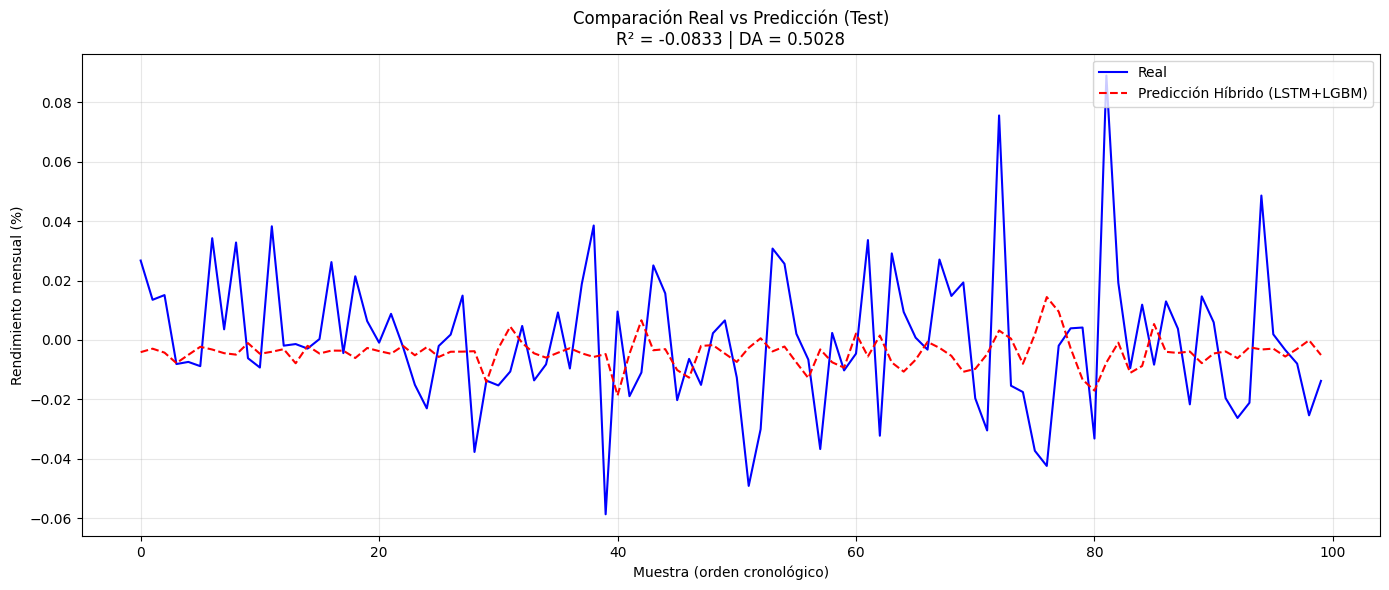

In [21]:
# %%
# ============================================
# GRÁFICA: REAL vs PREDICCIÓN (MODELO HÍBRIDO)
# ============================================

plt.figure(figsize=(14, 6))

# Mostrar muestras (últimas 100 o todas si son menos)
n_mostrar = min(100, len(y_test_seq))

# Crear índice para el eje X
indices = range(n_mostrar)

# Graficar
plt.plot(indices, y_test_seq[:n_mostrar], 
         label='Real', color='blue', linewidth=1.5)
plt.plot(indices, y_pred_hybrid[:n_mostrar], 
         label='Predicción Híbrido (LSTM+LGBM)', 
         color='red', linestyle='--', linewidth=1.5)

# Personalizar gráfica
plt.title(f'Comparación Real vs Predicción (Test)\nR² = {r2_score(y_test_seq, y_pred_hybrid):.4f} | DA = {directional_accuracy(y_test_seq, y_pred_hybrid):.4f}', 
          fontsize=12)
plt.xlabel('Muestra (orden cronológico)', fontsize=10)
plt.ylabel('Rendimiento mensual (%)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar (opcional)
plt.savefig('hibrido_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()